# 1. Importing Required Libraries

In this section, all required Python libraries for preprocessing, feature selection, model training, and evaluation are imported.

In [2]:
!pip install xgboost -q

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV,
    cross_val_score
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

from xgboost import XGBClassifier

# 2. Loading the HIGGS Dataset

The HIGGS dataset was downloaded from the UCI Machine Learning Repository. According to the project requirements, only the first 100,000 samples were used.

In [4]:
!wget -nc https://archive.ics.uci.edu/ml/machine-learning-databases/00280/HIGGS.csv.gz

--2026-06-27 06:55:12--  https://archive.ics.uci.edu/ml/machine-learning-databases/00280/HIGGS.csv.gz
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘HIGGS.csv.gz’

HIGGS.csv.gz            [   <=>              ]   2.62G  51.4MB/s    in 56s     

2026-06-27 06:56:09 (48.1 MB/s) - ‘HIGGS.csv.gz’ saved [2816407858]



In [5]:
df = pd.read_csv(
    "HIGGS.csv.gz",
    header=None,
    nrows=100000
)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (100000, 29)


,0,1,2,3,4,5,6,7,8,9,...,19,20,21,22,23,24,25,26,27,28
0,1.0,0.869293,-0.635082,0.225690,0.327470,-0.689993,0.754202,-0.248573,-1.092064,0.000000,...,-0.010455,-0.045767,3.101961,1.353760,0.979563,0.978076,0.920005,0.721657,0.988751,0.876678
1,1.0,0.907542,0.329147,0.359412,1.497970,-0.313010,1.095531,-0.557525,-1.588230,2.173076,...,-1.138930,-0.000819,0.000000,0.302220,0.833048,0.985700,0.978098,0.779732,0.992356,0.798343
2,1.0,0.798835,1.470639,-1.635975,0.453773,0.425629,1.104875,1.282322,1.381664,0.000000,...,1.128848,0.900461,0.000000,0.909753,1.108330,0.985692,0.951331,0.803252,0.865924,0.780118
3,0.0,1.344385,-0.876626,0.935913,1.992050,0.882454,1.786066,-1.646778,-0.942383,0.000000,...,-0.678379,-1.360356,0.000000,0.946652,1.028704,0.998656,0.728281,0.869200,1.026736,0.957904
4,1.0,1.105009,0.321356,1.522401,0.882808,-1.205349,0.681466,-1.070464,-0.921871,0.000000,...,-0.373566,0.113041,0.000000,0.755856,1.361057,0.986610,0.838085,1.133295,0.872245,0.808487


In [6]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100000, 28)
y shape: (100000,)


# 3. Outlier Analysis (IQR Method)

Outliers were detected using the Interquartile Range (IQR) method. Instead of removing them completely, extreme values were clipped to the threshold values to preserve the dataset size.

In [7]:
outlier_counts = {}

for col in X.columns:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((X[col] < lower) | (X[col] > upper)).sum()

    outlier_counts[col] = outliers

outlier_df = pd.DataFrame(
    outlier_counts.items(),
    columns=["Feature", "Outlier Count"]
)

outlier_df

,Feature,Outlier Count
0,1,3807
1,2,0
2,3,0
3,4,2907
4,5,0
5,6,4806
6,7,637
7,8,0
8,9,0
9,10,4048


In [8]:
X_clean = X.copy()

for col in X_clean.columns:

    Q1 = X_clean[col].quantile(0.25)
    Q3 = X_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    X_clean[col] = X_clean[col].clip(lower, upper)

print("Outlier processing completed!")

Outlier processing completed!


# 4. Feature Scaling

MinMaxScaler is applied to transform all features into the range [0,1].

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X_clean)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,1,2,3,4,5,6,7,8,9,10,...,19,20,21,22,23,24,25,26,27,28
0,0.307947,0.369674,0.564642,0.138072,0.302236,0.347995,0.455144,0.186400,0.0,0.650126,...,0.497833,0.486774,1.0,0.974328,0.515469,0.319991,0.443447,0.376123,0.507542,0.462063
1,0.327757,0.567714,0.603005,0.633534,0.410342,0.541378,0.398827,0.043934,1.0,0.341834,...,0.271924,0.499667,0.0,0.000000,0.360647,0.374465,0.484730,0.408553,0.510360,0.393215
2,0.271456,0.802160,0.030563,0.191535,0.622158,0.546672,0.734206,0.896692,0.0,0.363298,...,0.725909,0.758205,0.0,0.501213,0.651537,0.374411,0.465708,0.421687,0.411542,0.377197
3,0.554002,0.320064,0.768393,0.842673,0.753160,0.932607,0.200271,0.229379,0.0,1.000000,...,0.364121,0.109675,0.0,0.540531,0.567395,0.467044,0.307202,0.458515,0.537231,0.533450
4,0.430027,0.566113,0.936646,0.373141,0.154450,0.306786,0.305325,0.235268,0.0,0.335415,...,0.425142,0.532329,0.0,0.337226,0.918592,0.380967,0.385232,0.605994,0.416482,0.402130


In [10]:
print("Minimum value:", X_scaled.min().min())
print("Maximum value:", X_scaled.max().max())

Minimum value: 0.0
Maximum value: 1.0000000000000002


# 5. Feature Selection

ANOVA F-score is used to select the top 15 features.

In [11]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(
    score_func=f_classif,
    k=15
)

X_selected = selector.fit_transform(X_scaled, y)

In [12]:
selected_features = X.columns[selector.get_support()]

print("Selected Features:")
print(selected_features)

Selected Features:
Index([1, 4, 6, 10, 13, 14, 17, 18, 21, 22, 23, 24, 26, 27, 28], dtype='int64')


In [13]:
X_selected = pd.DataFrame(
    X_selected,
    columns=selected_features
)

X_selected.head()

,1,4,6,10,13,14,17,18,21,22,23,24,26,27,28
0,0.307947,0.138072,0.347995,0.650126,0.5,0.483977,0.0,0.166220,1.0,0.974328,0.515469,0.319991,0.376123,0.507542,0.462063
1,0.327757,0.633534,0.541378,0.341834,1.0,0.130705,0.0,0.018945,0.0,0.000000,0.360647,0.374465,0.408553,0.510360,0.393215
2,0.271456,0.191535,0.546672,0.363298,1.0,0.403574,1.0,0.506543,0.0,0.501213,0.651537,0.374411,0.421687,0.411542,0.377197
3,0.554002,0.842673,0.932607,1.000000,1.0,0.572344,0.0,0.215865,0.0,0.540531,0.567395,0.467044,0.458515,0.537231,0.533450
4,0.430027,0.373141,0.306786,0.335415,1.0,0.184211,0.0,0.065133,0.0,0.337226,0.918592,0.380967,0.605994,0.416482,0.402130


# 6. KNN Model

Nested Cross Validation (5 outer folds, 3 inner folds) is performed for KNN.

In [14]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

outer_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

inner_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [15]:
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11]
}

In [16]:
knn_results = []

fold = 1

for train_idx, test_idx in outer_cv.split(X_selected, y):

    print(f"Processing Fold {fold}/5")

    X_train = X_selected.iloc[train_idx]
    X_test = X_selected.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    grid = GridSearchCV(
        KNeighborsClassifier(),
        knn_params,
        cv=inner_cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    knn_results.append({
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob)
    })

    print("Best Parameters:", grid.best_params_)

    fold += 1

Processing Fold 1/5
Best Parameters: {'n_neighbors': 11}
Processing Fold 2/5
Best Parameters: {'n_neighbors': 11}
Processing Fold 3/5
Best Parameters: {'n_neighbors': 11}
Processing Fold 4/5
Best Parameters: {'n_neighbors': 11}
Processing Fold 5/5
Best Parameters: {'n_neighbors': 11}


In [17]:
import pandas as pd

knn_df = pd.DataFrame(knn_results)

print(knn_df.mean())

accuracy     0.663810
precision    0.667091
recall       0.725991
f1           0.695296
roc_auc      0.719159
dtype: float64


# 7. Support Vector Machine (SVM)

A subset of 20,000 samples is used due to computational limitations.

In [18]:
svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

In [19]:
mlp_params = {
    'hidden_layer_sizes': [(50,), (100,)],
    'activation': ['relu', 'tanh']
}

In [20]:
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.1]
}

In [23]:
svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}
X_svm = X_selected.iloc[:20000]
y_svm = y.iloc[:20000]

print(X_svm.shape)
print(y_svm.shape)

(20000, 15)
(20000,)


# 8. Multi-Layer Perceptron (MLP)

In [24]:
from sklearn.svm import SVC

svm_results = []

fold = 1

for train_idx, test_idx in outer_cv.split(X_svm, y_svm):

    print(f"Processing Fold {fold}/5")

    X_train = X_svm.iloc[train_idx]
    X_test = X_svm.iloc[test_idx]

    y_train = y_svm.iloc[train_idx]
    y_test = y_svm.iloc[test_idx]

    grid = GridSearchCV(
        SVC(probability=True),
        svm_params,
        cv=inner_cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    svm_results.append({
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob)
    })

    print("Best Parameters:", grid.best_params_)

    fold += 1

Processing Fold 1/5
Best Parameters: {'C': 1, 'kernel': 'rbf'}
Processing Fold 2/5
Best Parameters: {'C': 10, 'kernel': 'rbf'}
Processing Fold 3/5
Best Parameters: {'C': 1, 'kernel': 'rbf'}
Processing Fold 4/5
Best Parameters: {'C': 1, 'kernel': 'rbf'}
Processing Fold 5/5
Best Parameters: {'C': 10, 'kernel': 'rbf'}


In [25]:
svm_df = pd.DataFrame(svm_results)

print(svm_df.mean())

accuracy     0.684000
precision    0.679620
recall       0.749451
f1           0.712659
roc_auc      0.746640
dtype: float64


In [26]:
X_mlp = X_selected.iloc[:20000]
y_mlp = y.iloc[:20000]

print(X_mlp.shape)

(20000, 15)


In [27]:
mlp_params = {
    'hidden_layer_sizes': [(50,), (100,)],
    'activation': ['relu', 'tanh']
}

# 9. XGBoost Model

In [28]:
from sklearn.neural_network import MLPClassifier

mlp_results = []

fold = 1

for train_idx, test_idx in outer_cv.split(X_mlp, y_mlp):

    print(f"Processing Fold {fold}/5")

    X_train = X_mlp.iloc[train_idx]
    X_test = X_mlp.iloc[test_idx]

    y_train = y_mlp.iloc[train_idx]
    y_test = y_mlp.iloc[test_idx]

    grid = GridSearchCV(
        MLPClassifier(
            max_iter=200,
            random_state=42
        ),
        mlp_params,
        cv=inner_cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    mlp_results.append({
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob)
    })

    print("Best Parameters:", grid.best_params_)

    fold += 1

Processing Fold 1/5
Best Parameters: {'activation': 'relu', 'hidden_layer_sizes': (100,)}
Processing Fold 2/5
Best Parameters: {'activation': 'relu', 'hidden_layer_sizes': (100,)}
Processing Fold 3/5
Best Parameters: {'activation': 'relu', 'hidden_layer_sizes': (100,)}
Processing Fold 4/5
Best Parameters: {'activation': 'relu', 'hidden_layer_sizes': (100,)}
Processing Fold 5/5
Best Parameters: {'activation': 'relu', 'hidden_layer_sizes': (100,)}


In [29]:
mlp_df = pd.DataFrame(mlp_results)

print(mlp_df.mean())

accuracy     0.700300
precision    0.701476
recall       0.744197
f1           0.721723
roc_auc      0.767814
dtype: float64


In [30]:
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.1]
}

In [31]:
X_xgb = X_selected.iloc[:20000]
y_xgb = y.iloc[:20000]

print(X_xgb.shape)

(20000, 15)


In [32]:
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.1]
}

# 10. Experimental Results

In [33]:
from xgboost import XGBClassifier

xgb_results = []

fold = 1

for train_idx, test_idx in outer_cv.split(X_xgb, y_xgb):

    print(f"Processing Fold {fold}/5")

    X_train = X_xgb.iloc[train_idx]
    X_test = X_xgb.iloc[test_idx]

    y_train = y_xgb.iloc[train_idx]
    y_test = y_xgb.iloc[test_idx]

    grid = GridSearchCV(
        XGBClassifier(
            random_state=42,
            eval_metric='logloss'
        ),
        xgb_params,
        cv=inner_cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    xgb_results.append({
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob)
    })

    print("Best Parameters:", grid.best_params_)

    fold += 1

Processing Fold 1/5
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Processing Fold 2/5
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Processing Fold 3/5
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Processing Fold 4/5
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Processing Fold 5/5
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}


In [34]:
xgb_df = pd.DataFrame(xgb_results)

print(xgb_df.mean())

accuracy     0.703850
precision    0.718116
recall       0.714068
f1           0.716046
roc_auc      0.779016
dtype: float64


In [35]:
results = pd.DataFrame({
    "Model": ["KNN", "SVM", "MLP", "XGBoost"],
    "Accuracy": [
        knn_df["accuracy"].mean(),
        svm_df["accuracy"].mean(),
        mlp_df["accuracy"].mean(),
        xgb_df["accuracy"].mean()
    ],
    "Precision": [
        knn_df["precision"].mean(),
        svm_df["precision"].mean(),
        mlp_df["precision"].mean(),
        xgb_df["precision"].mean()
    ],
    "Recall": [
        knn_df["recall"].mean(),
        svm_df["recall"].mean(),
        mlp_df["recall"].mean(),
        xgb_df["recall"].mean()
    ],
    "F1": [
        knn_df["f1"].mean(),
        svm_df["f1"].mean(),
        mlp_df["f1"].mean(),
        xgb_df["f1"].mean()
    ],
    "ROC_AUC": [
        knn_df["roc_auc"].mean(),
        svm_df["roc_auc"].mean(),
        mlp_df["roc_auc"].mean(),
        xgb_df["roc_auc"].mean()
    ]
})

results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,KNN,0.66381,0.667091,0.725991,0.695296,0.719159
1,SVM,0.68400,0.679620,0.749451,0.712659,0.746640
2,MLP,0.70030,0.701476,0.744197,0.721723,0.767814
3,XGBoost,0.70385,0.718116,0.714068,0.716046,0.779016


In [36]:
best_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

best_model.fit(X_xgb, y_xgb)

y_prob = best_model.predict_proba(X_xgb)[:, 1]

# 11. ROC Curve Analysis

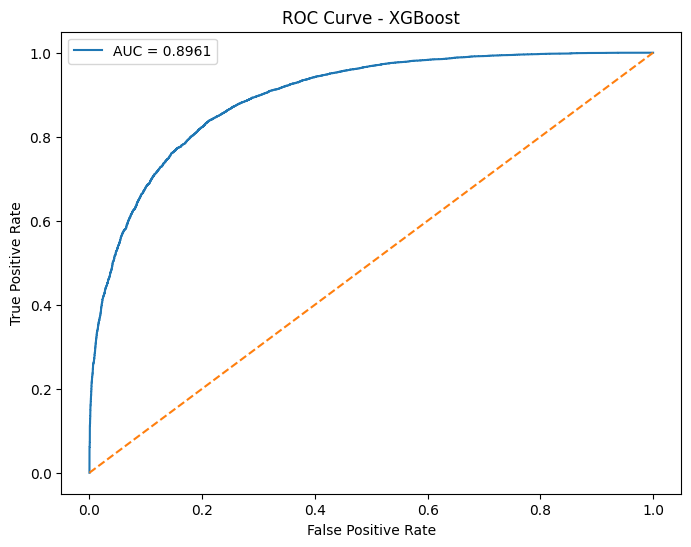

In [37]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_xgb, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()

plt.show()

In [38]:
feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Selected": selector.get_support()
})

feature_scores[feature_scores["Selected"]]

,Feature,Selected
0,1,True
3,4,True
5,6,True
9,10,True
12,13,True
13,14,True
16,17,True
17,18,True
20,21,True
21,22,True
